In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings(action='once')
import random
import math

In [3]:
df = pd.read_csv("batdongsan.com.vn.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 81163 entries, 0 to 81162
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         81163 non-null  int64  
 1   month      81162 non-null  float64
 2   project    78097 non-null  str    
 3   investor   65453 non-null  str    
 4   square     81162 non-null  float64
 5   bedrooms   81162 non-null  float64
 6   bathrooms  81162 non-null  float64
 7   direction  51086 non-null  str    
 8   balcony    54426 non-null  str    
 9   district   81162 non-null  str    
 10  ward       79506 non-null  str    
 11  price      81162 non-null  float64
dtypes: float64(5), int64(1), str(6)
memory usage: 7.4 MB


c:\Users\admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


<Axes: xlabel='price'>

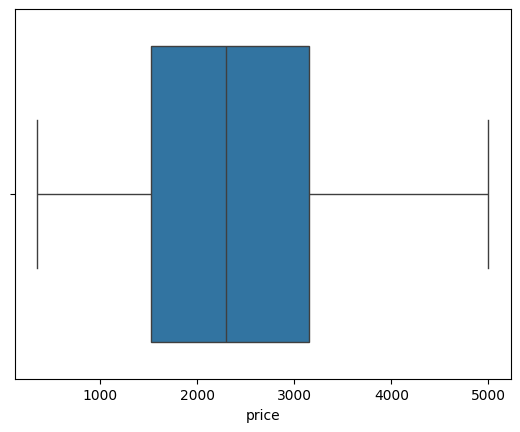

In [4]:
sns.boxplot(x=df.price)

c:\Users\admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


<Axes: xlabel='square'>

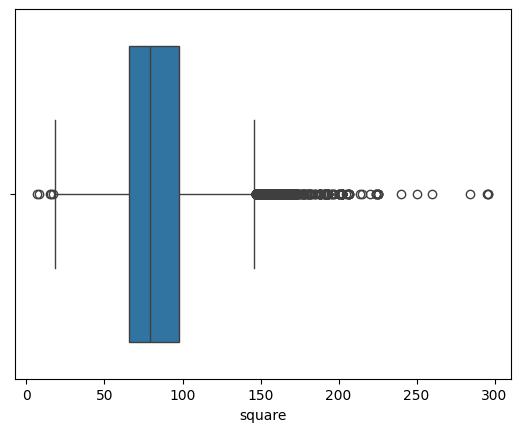

In [5]:
sns.boxplot(x=df.square)

c:\Users\admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


<Axes: xlabel='bathrooms'>

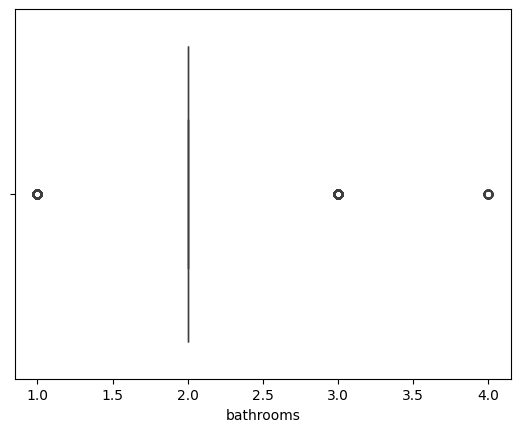

In [6]:
sns.boxplot(x=df.bathrooms)

c:\Users\admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


<Axes: xlabel='bedrooms'>

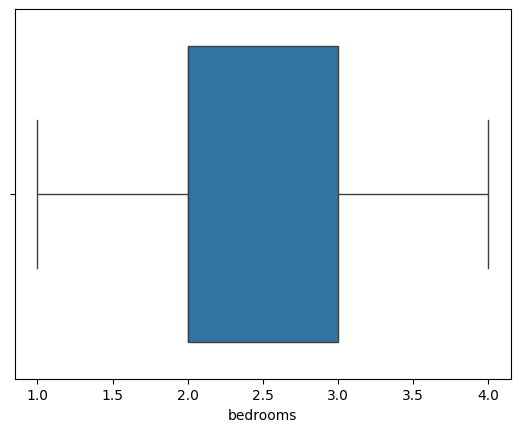

In [7]:
sns.boxplot(x=df.bedrooms)

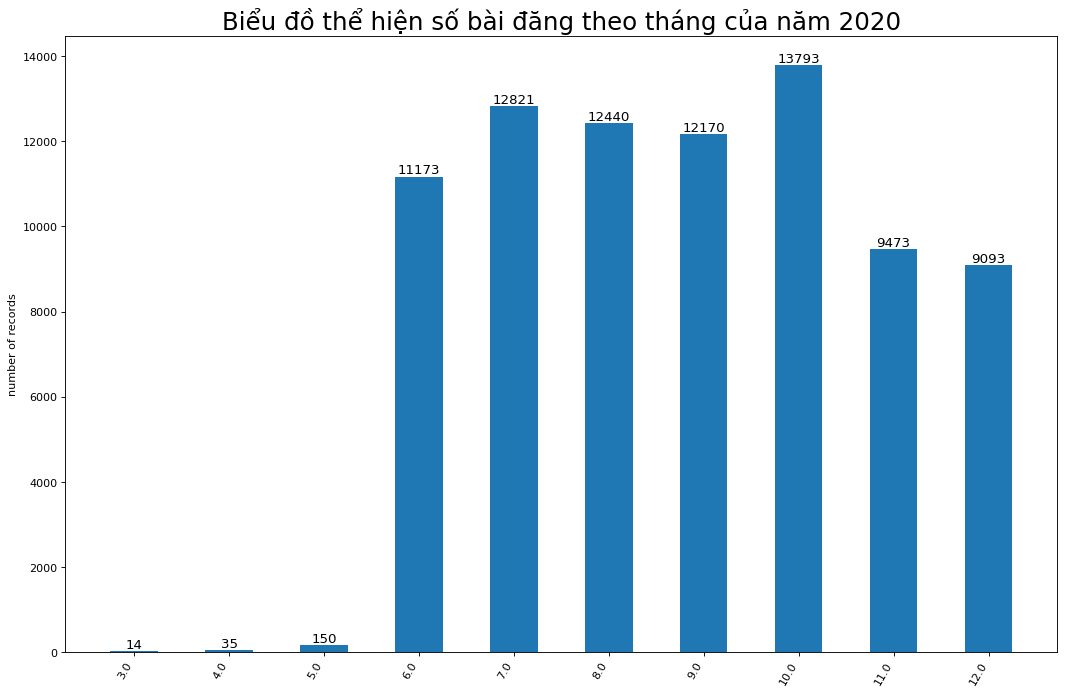

In [8]:
df1 = df.groupby('month').size().reset_index(name='number of records')


plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df1['month'], df1['number of records'],  width=.5)
for i, val in enumerate(df1['number of records'].values, 3):
    plt.text(i, val, val, horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

plt.xticks(df1['month'], df1['month'].astype(str), rotation=60, ha='right')
plt.title("Biểu đồ thể hiện số bài đăng theo tháng của năm 2020", fontsize=22)
plt.ylabel('number of records')
plt.show()

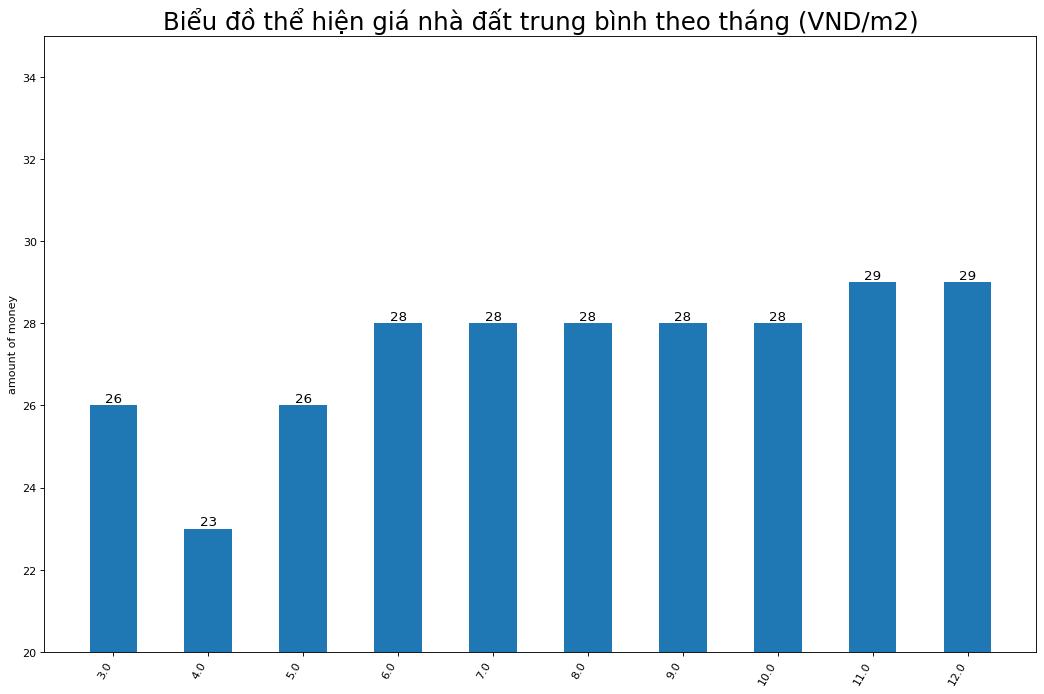

In [9]:

dftmp = df.copy()
dftmp['pricePerSquare'] = dftmp.price / dftmp.square
df2 = dftmp.groupby('month')['pricePerSquare'].mean().reset_index(name='amount of money')
df2['amount of money'] = df2['amount of money'].apply(lambda x : int(str(x).split('.')[0]))

plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df2['month'], df2['amount of money'], width=0.5)
for i, val in enumerate(df2['amount of money'].values, int(df2.month[0])):
    plt.text(i, val, val, horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

plt.gca().set_xticks(df2['month'], df2.month, rotation=60, horizontalalignment= 'right')
plt.title("Biểu đồ thể hiện giá nhà đất trung bình theo tháng (VND/m2)", fontsize=22)
plt.ylabel('amount of money')
plt.ylim(20,35)
plt.show()

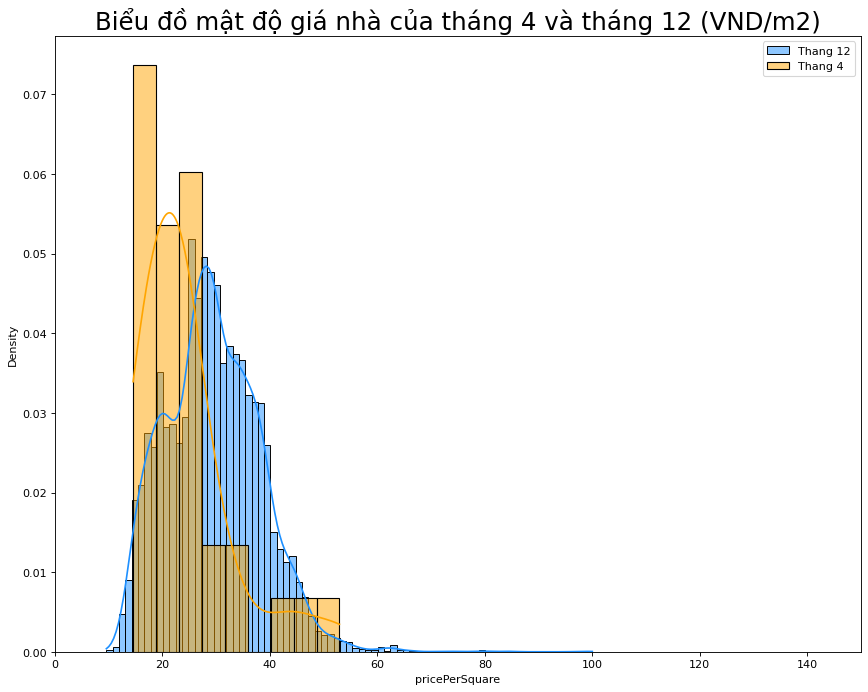

In [10]:
plt.figure(figsize=(13,10), dpi= 80)
sns.histplot(dftmp.loc[dftmp['month'] == 12, "pricePerSquare"],color="dodgerblue", label="Thang 12", kde=True, stat='density')
sns.histplot(dftmp.loc[dftmp['month'] == 4, "pricePerSquare"], color="orange", label="Thang 4", kde=True, stat='density')
plt.xlim(0, 150)
plt.title('Biểu đồ mật độ giá nhà của tháng 4 và tháng 12 (VND/m2)', fontsize=22)
plt.legend()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_10828\4006978214.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df3['bedrooms'], rotation=60, horizontalalignment= 'right')


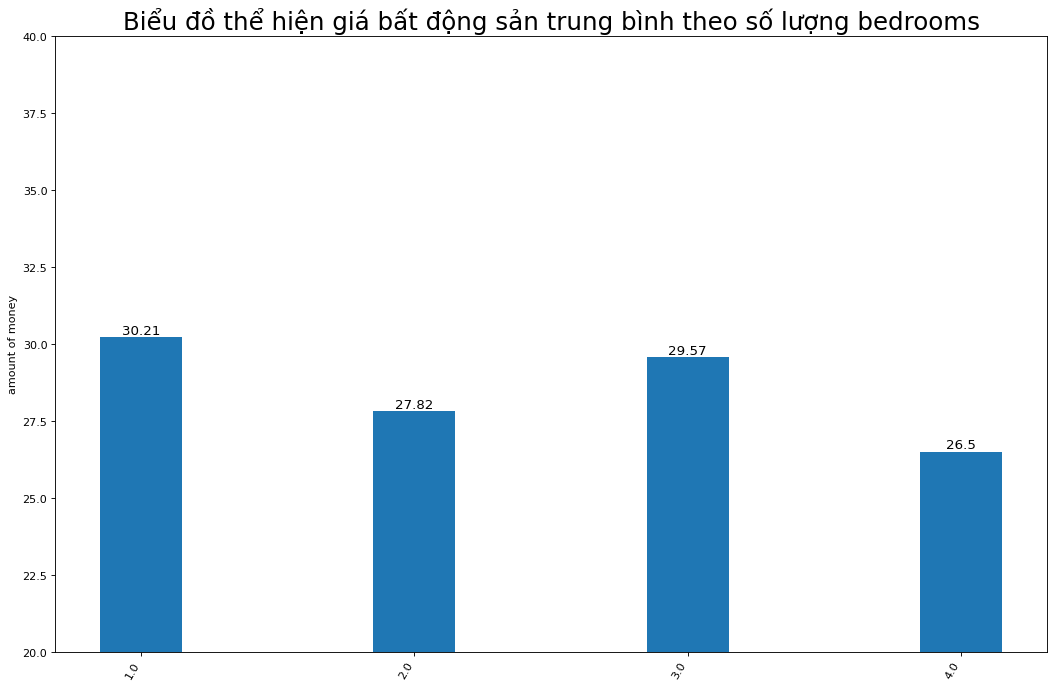

In [11]:
df3 = dftmp.groupby('bedrooms')['pricePerSquare'].mean().reset_index(name='amount of money')

df3['amount of money'] = df3['amount of money'].apply(lambda x : round(x, 2))
df3['bedrooms'] = df3['bedrooms'].astype(str)

plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df3['bedrooms'], df3['amount of money'], width=.3)
for i, val in enumerate(df3['amount of money'].values):
    plt.text(i, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

plt.gca().set_xticklabels(df3['bedrooms'], rotation=60, horizontalalignment= 'right')
plt.title("Biểu đồ thể hiện giá bất động sản trung bình theo số lượng bedrooms", fontsize=22)
plt.ylim(20,40)
plt.ylabel('amount of money')
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_10828\1172603839.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df2['district'], rotation=60, horizontalalignment= 'right')


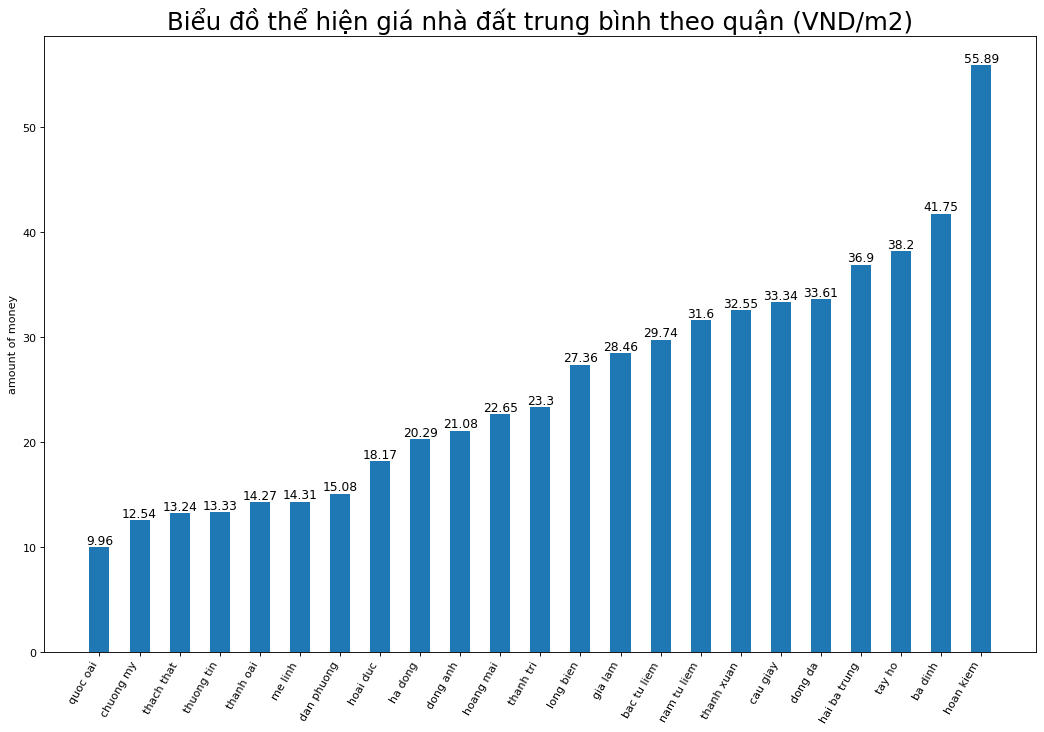

In [12]:
df2 = dftmp.groupby('district')['pricePerSquare'].mean().reset_index(name='amount of money')
df2 = df2.sort_values(by = 'amount of money') 
# df2['amount of money'] = df2['amount of money'].apply(lambda x : int(str(x).split('.')[0]))
df2['amount of money'] = df2['amount of money'].apply(lambda x : round(x, 2))

plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df2['district'], df2['amount of money'], width=.5)
for i, val in enumerate(df2['amount of money'].values):
    plt.text(i, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':450, 'size':11})

plt.gca().set_xticklabels(df2['district'], rotation=60, horizontalalignment= 'right')
plt.title("Biểu đồ thể hiện giá nhà đất trung bình theo quận (VND/m2)", fontsize=22)
plt.ylabel('amount of money')
# plt.ylim(25,35)
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_10828\3425485650.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df2['ward'], rotation=60, horizontalalignment= 'right')


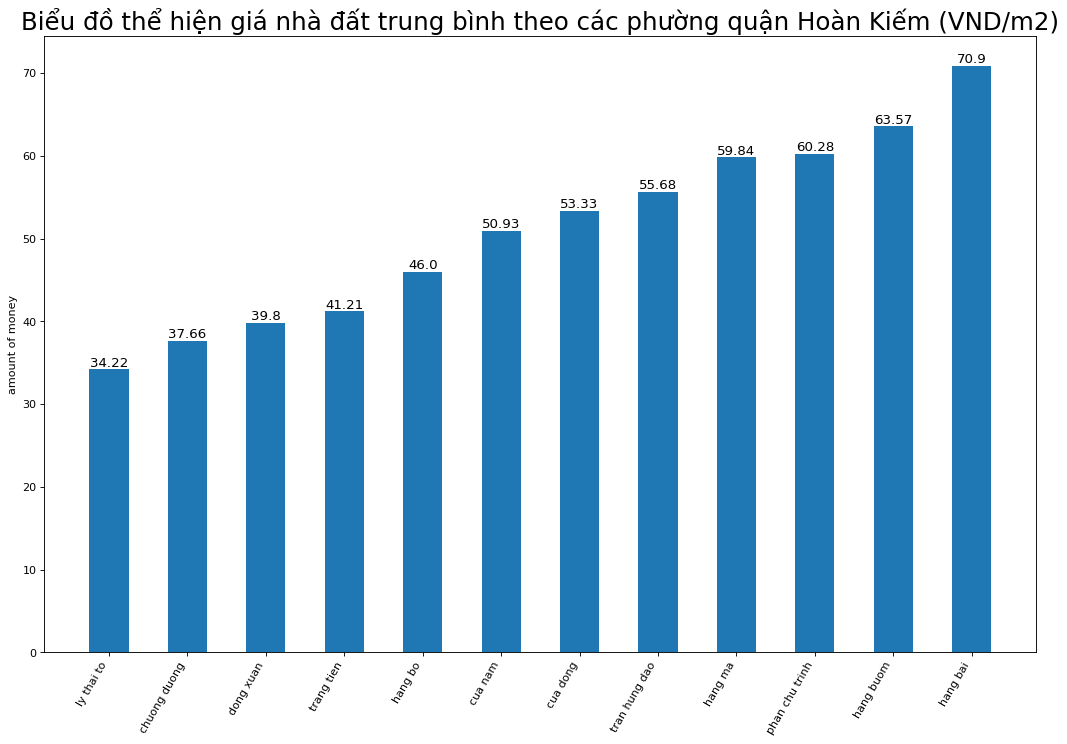

In [13]:
hoan_kiem = dftmp[(dftmp['district'] == 'hoan kiem')]
df2 = hoan_kiem.groupby('ward')['pricePerSquare'].mean().reset_index(name='amount of money')
df2 = df2.sort_values(by = 'amount of money') 

df2['amount of money'] = df2['amount of money'].apply(lambda x : round(x, 2))


plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df2['ward'], df2['amount of money'], width=.5)
for i, val in enumerate(df2['amount of money'].values):
    plt.text(i, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

plt.gca().set_xticklabels(df2['ward'], rotation=60, horizontalalignment= 'right')
plt.title("Biểu đồ thể hiện giá nhà đất trung bình theo các phường quận Hoàn Kiếm (VND/m2)", fontsize=22)
plt.ylabel('amount of money')

plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_10828\3759130706.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df2['investor'], rotation=60, horizontalalignment= 'right')


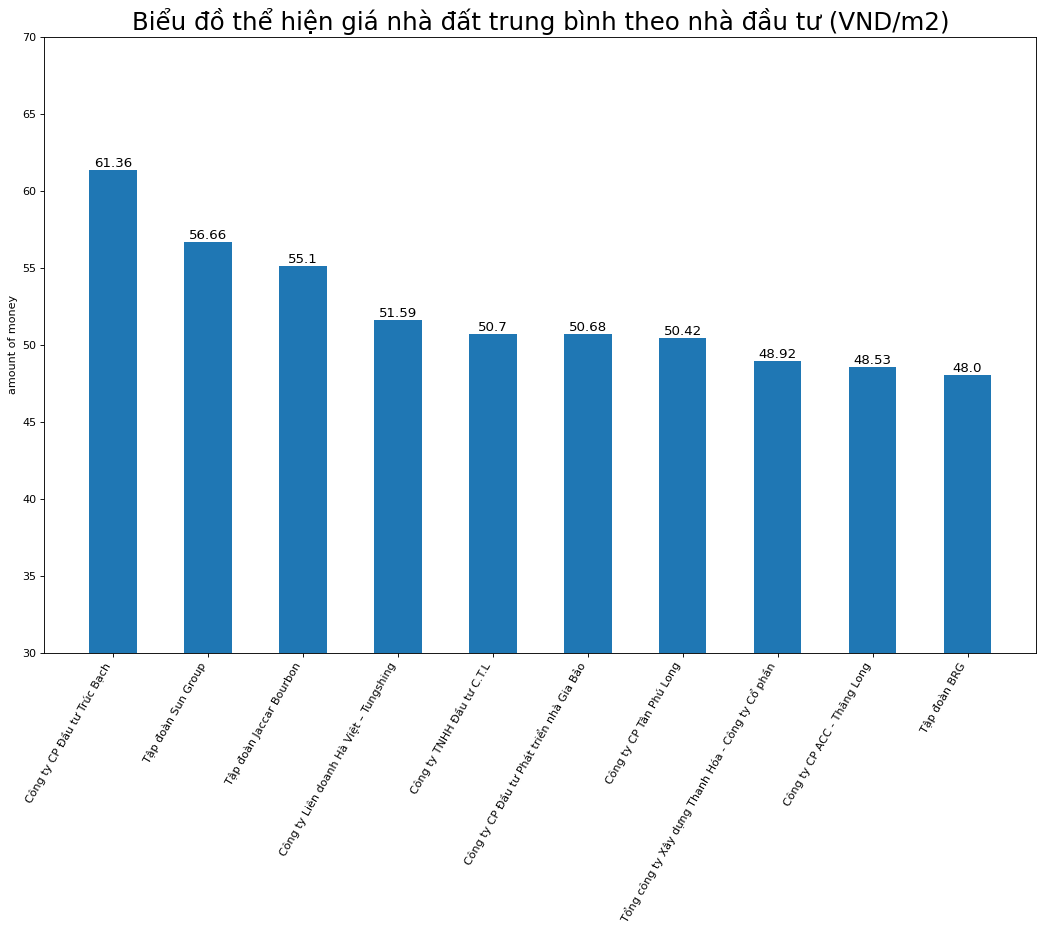

In [17]:
df2 = dftmp.groupby('investor')['pricePerSquare'].mean().reset_index(name='amount of money')
df2 = df2.sort_values(by = 'amount of money', ascending= False).head(10)

df2['amount of money'] = df2['amount of money'].apply(lambda x : round(x, 2))



plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df2['investor'], df2['amount of money'], width=0.5)
for i, val in enumerate(df2['amount of money'].values):
    plt.text(i, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

plt.gca().set_xticklabels(df2['investor'], rotation=60, horizontalalignment= 'right')
plt.title("Biểu đồ thể hiện giá nhà đất trung bình theo nhà đầu tư (VND/m2)", fontsize=22)
plt.ylabel('amount of money')
plt.ylim(30,70)
plt.show()

246                   Hà Nội Golden Lake
596      Vinhomes Metropolis - Liễu Giai
477    Sun Grand City Quảng An Residence
229                        Hateco Laroma
550                   Trúc Bạch Building
359                      Liễu Giai Tower
475                       Sun Grand City
597            Vinhomes Nguyễn Chí Thanh
427                        Pacific Place
240                    Hoàng Cầu Skyline
Name: project, dtype: str
             id  month                          project  \
217    27988796   12.0                   Sun Grand City   
320    28111000   12.0                  Liễu Giai Tower   
382    24458492   12.0        Vinhomes Nguyễn Chí Thanh   
633    28125955   12.0        Vinhomes Nguyễn Chí Thanh   
679    25436762   12.0        Vinhomes Nguyễn Chí Thanh   
...         ...    ...                              ...   
74247  25937912    6.0  Vinhomes Metropolis - Liễu Giai   
74265  25567443    6.0                Hoàng Cầu Skyline   
75470  25907355    6.0           

C:\Users\admin\AppData\Local\Temp\ipykernel_10828\4087454813.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df7['project'], rotation=60, horizontalalignment= 'right')


Text(0.5, 1.0, 'Giá bất động sản phân bố theo dự án triệu VND/m2 ')

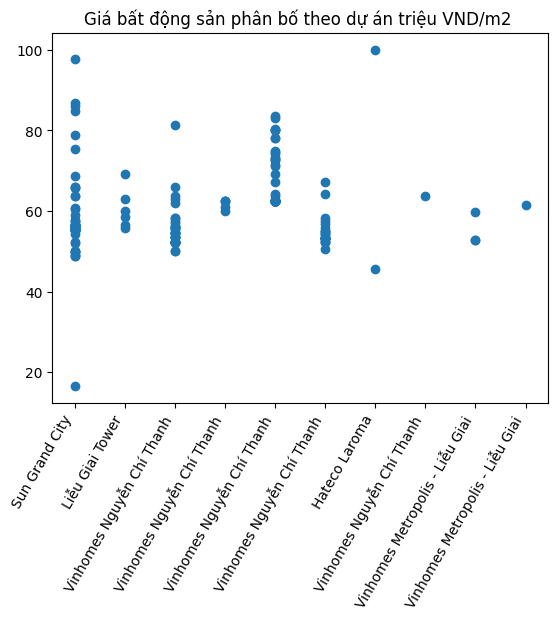

In [20]:
pr = dftmp[dftmp['project'].notnull()]
pr = pr.groupby('project')['pricePerSquare'].mean().reset_index(name='amount of money')
pr = pr.sort_values(by = 'amount of money', ascending= False).head(10)
protop = pr['project']
print(protop)
df7 = dftmp.loc[(dftmp['project'].isin(protop))]
print(df7)
plt.scatter(df7.project, df7.pricePerSquare)
# plt.ylim(0,150)
plt.gca().set_xticklabels(df7['project'], rotation=60, horizontalalignment= 'right')
plt.title("Giá bất động sản phân bố theo dự án triệu VND/m2 ")

(0.0, 100.0)

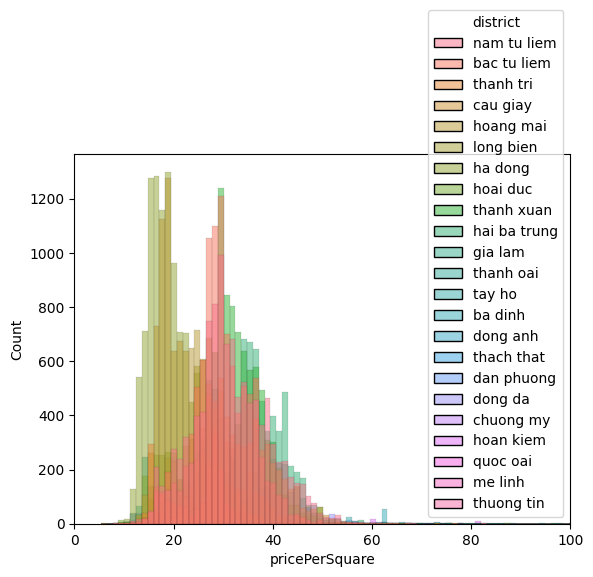

In [22]:

df5 = dftmp.copy()
plt.clf()
sns.histplot(df5, x="pricePerSquare", hue="district")
plt.xlim(0, 100)